<a href="https://colab.research.google.com/github/aswinrj401-del/AI-DEEP-VISION/blob/main/DAY4emotion_recog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip /content/emotion1.zip -d /content/

Archive:  /content/emotion1.zip
   creating: /content/emotion1/angry/
  inflating: /content/emotion1/angry/angry1.jpg  
  inflating: /content/emotion1/angry/angry10.jpg  
  inflating: /content/emotion1/angry/angry2.jpg  
  inflating: /content/emotion1/angry/angry3.jpg  
  inflating: /content/emotion1/angry/angry4.jpg  
  inflating: /content/emotion1/angry/angry5.jpg  
  inflating: /content/emotion1/angry/angry6.jpg  
  inflating: /content/emotion1/angry/angry7.jpg  
  inflating: /content/emotion1/angry/angry8.jpg  
  inflating: /content/emotion1/angry/angry9.jpg  
   creating: /content/emotion1/happy/
  inflating: /content/emotion1/happy/happy1.jpg  
  inflating: /content/emotion1/happy/happy1o.jpg  
  inflating: /content/emotion1/happy/happy2.jpg  
  inflating: /content/emotion1/happy/happy3.jpg  
  inflating: /content/emotion1/happy/happy4.jpg  
  inflating: /content/emotion1/happy/happy5.jpg  
  inflating: /content/emotion1/happy/happy6.jpg  
  inflating: /content/emotion1/happy/hap

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
dataset_path = "/content/emotion1"

IMG_SIZE = (128,128)
BATCH_SIZE = 8

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print(class_names)

Found 40 files belonging to 4 classes.
Using 32 files for training.
Found 40 files belonging to 4 classes.
Using 8 files for validation.
['angry', 'happy', 'sad', 'tensed']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(100).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

In [ ]:
model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(16,(3,3),activation="relu"),

    layers.MaxPooling2D(),

    layers.Conv2D(32,(3,3),activation="relu"),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(64,activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(4,activation="softmax")

])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=30

)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.1875 - loss: 2.2987 - val_accuracy: 0.3750 - val_loss: 1.7702
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2188 - loss: 1.4919 - val_accuracy: 0.1250 - val_loss: 1.4045
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3750 - loss: 1.3117 - val_accuracy: 0.3750 - val_loss: 1.3391
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4062 - loss: 1.3293 - val_accuracy: 0.2500 - val_loss: 1.3572
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5312 - loss: 1.2321 - val_accuracy: 0.2500 - val_loss: 1.4027
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5312 - loss: 1.1422 - val_accuracy: 0.5000 - val_loss: 1.4062
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5625 - loss: 1.0942 - val_accuracy: 0.6250 - val_loss: 1.5034
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5938 - loss: 1.0508 - val_accuracy: 0.3750 - val_loss: 2.0178

In [ ]:
loss,accuracy = model.evaluate(validation_dataset)

print("Accuracy :",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3750 - loss: 1.6525
Accuracy : 0.375


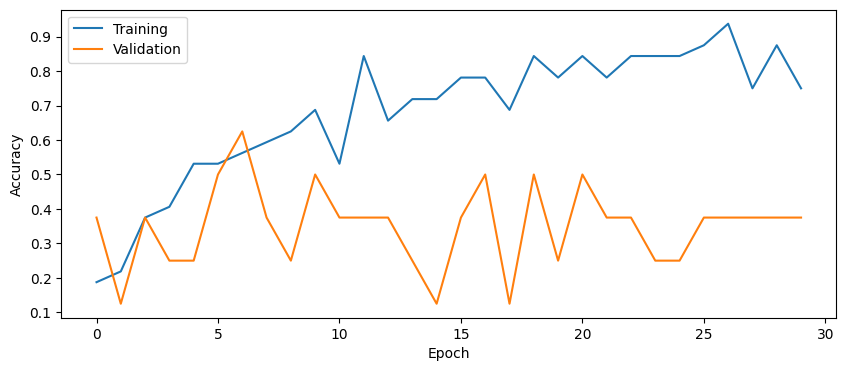

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

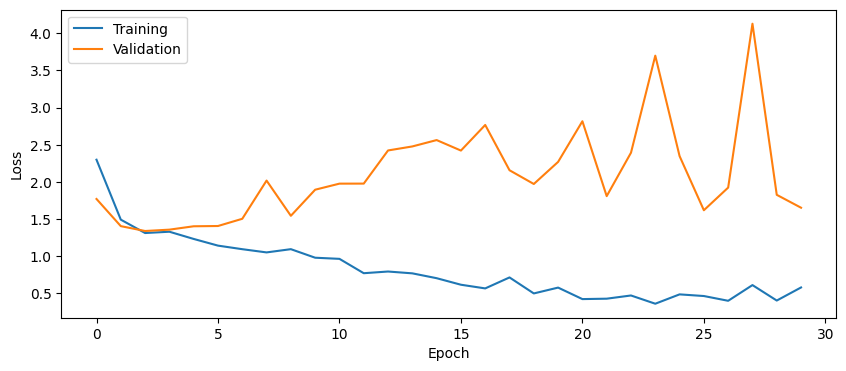

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history.history["loss"],label="Training")

plt.plot(history.history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
predictions = model.predict(validation_dataset)

predicted_labels = np.argmax(predictions,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


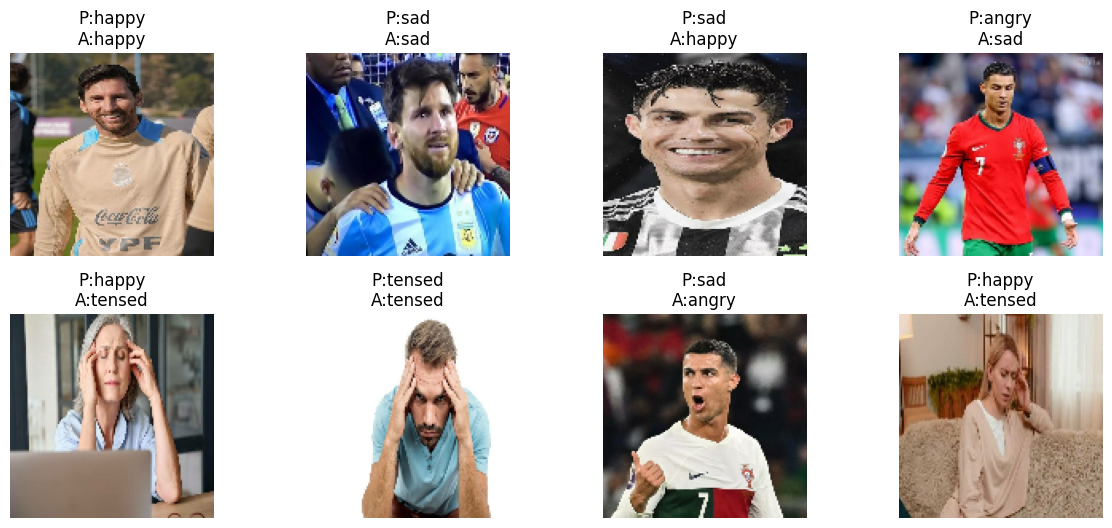

In [ ]:
index = 0

plt.figure(figsize=(12,8))

for images,labels in validation_dataset:

    images = images.numpy()

    labels = labels.numpy()

    for i in range(len(images)):

        plt.subplot(3,4,index+1)

        plt.imshow(images[i].astype("uint8"))

        actual = class_names[labels[i]]

        predicted = class_names[predicted_labels[index]]

        plt.title(f"P:{predicted}\nA:{actual}")

        plt.axis("off")

        index += 1

        if index==12:
            break

    if index==12:
        break

plt.tight_layout()

plt.show()

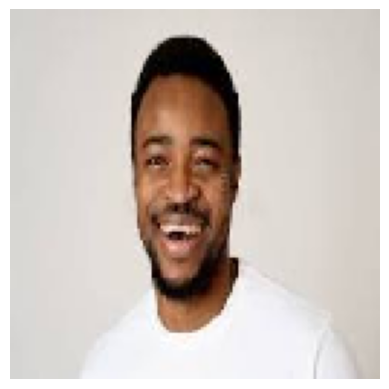

In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "/content/test2.jpeg",
    target_size=(128,128)
)

plt.imshow(img)

plt.axis("off")

plt.show()

In [ ]:
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)

In [ ]:
layers.Rescaling(1./255)

<Rescaling name=rescaling_4, built=False>

In [ ]:
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100

print("Prediction :",predicted_class)

print("Confidence :",confidence,"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction : happy
Confidence : 92.79718 %


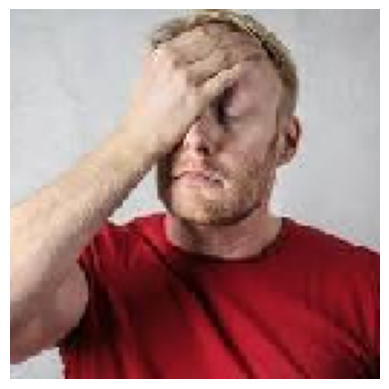

In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "/content/tes4.jpeg",
    target_size=(128,128)
)

plt.imshow(img)

plt.axis("off")

plt.show()

In [ ]:
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)

In [ ]:
layers.Rescaling(1./255)

<Rescaling name=rescaling_8, built=False>

In [ ]:
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100

print("Prediction :",predicted_class)

print("Confidence :",confidence,"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction : angry
Confidence : 50.29232 %


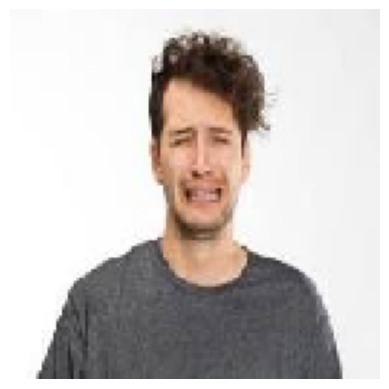

In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "/content/test1.jpeg",
    target_size=(128,128)
)

plt.imshow(img)

plt.axis("off")

plt.show()

In [ ]:
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)

In [ ]:
layers.Rescaling(1./255)

<Rescaling name=rescaling_7, built=False>

In [ ]:
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100

print("Prediction :",predicted_class)

print("Confidence :",confidence,"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction : happy
Confidence : 53.784126 %
